In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 16})

In [2]:
bmu = np.load("data/bmu.npy")
Y = np.load("data/Y.npy")

In [3]:
som_shape = (45, 45)
som_size = np.prod(som_shape)

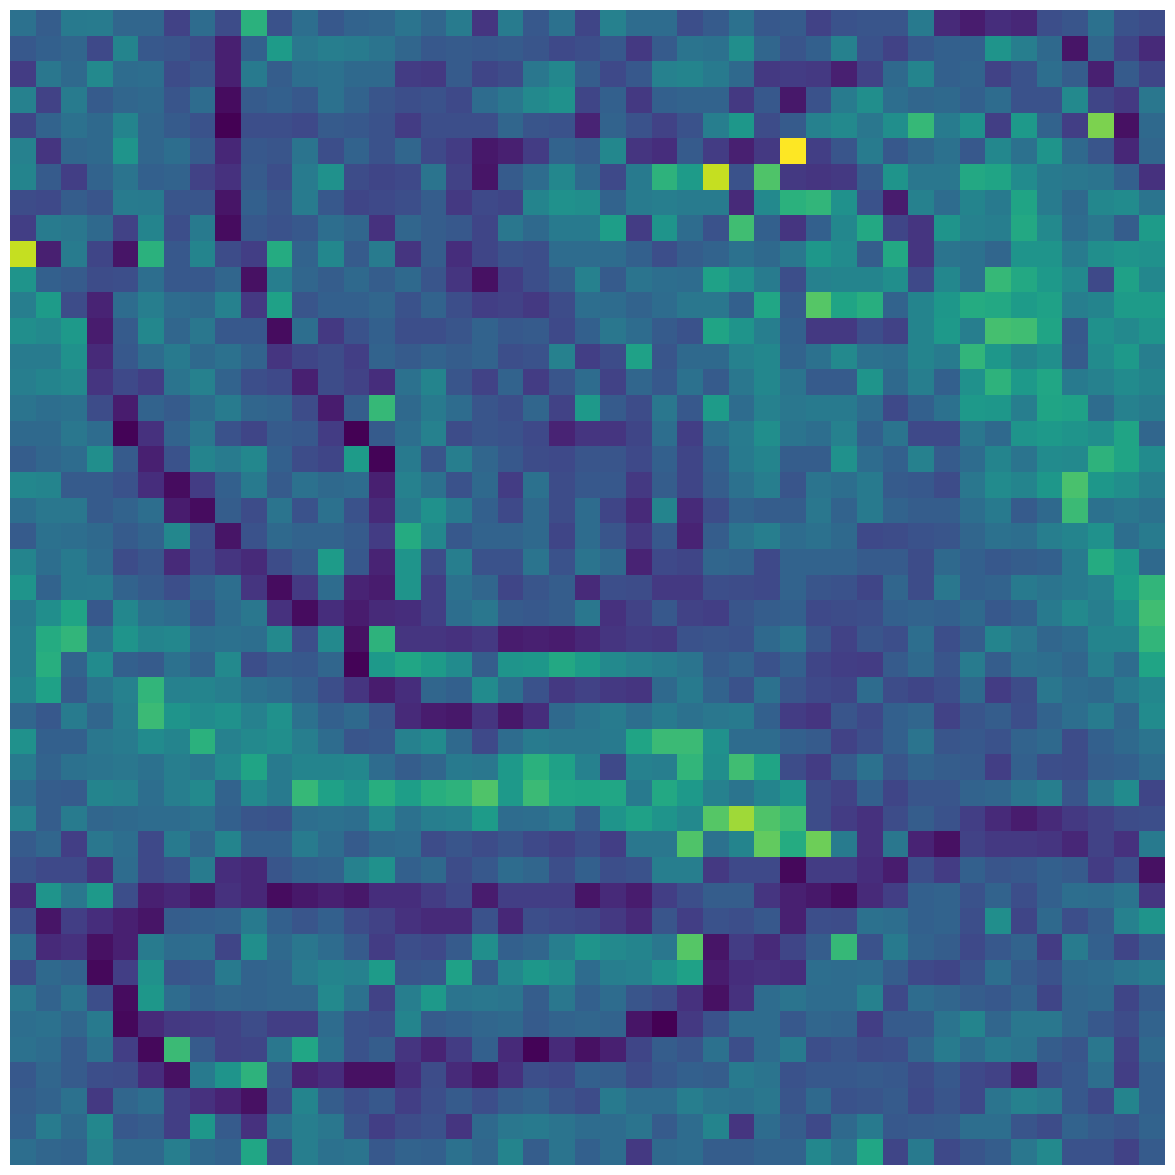

In [4]:
def plot_entire_bmu(bmu):
    counts = np.bincount(bmu, minlength=som_size)
    
    counts = counts.reshape(som_shape)
    counts.dtype = float
    
    fig, ax = plt.subplots(figsize=(15, 15))
    
    percentile_cut = 15
    good_pixels = counts > np.percentile(counts, percentile_cut)
    # counts[~good_pixels] = np.nan

    cmap = plt.cm.viridis.copy()
    cmap.set_bad("red")

    ax.axis("off")
    ax.imshow(counts, cmap=cmap)
    # plt.savefig("som_trained_dr12_test_dr12.jpg", bbox_inches="tight", pad_inches=0)
    
plot_entire_bmu(bmu)

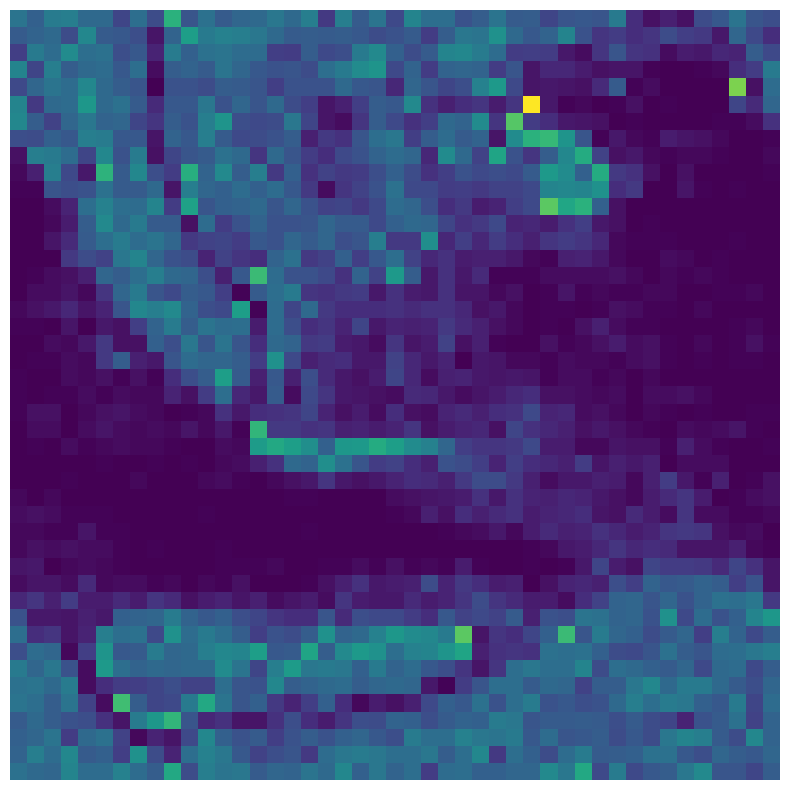

In [5]:
label_names = ["STAR", "GALAXY", "QSO_LZ", "QSO_HZ", "BAD"]

def plot_bmu(label="STAR"):
    labels = np.argmax(Y[0:len(bmu)], axis=1)
    
    # Switch to combine qso measurements
    if label == "QSO":
        idx = (labels == label_names.index("QSO_LZ")) | (labels == label_names.index("QSO_HZ"))
    else:
        idx = labels == label_names.index(label)
    idx = idx.flatten()
    counts = np.bincount(bmu[idx], minlength=som_size)
    
    counts = counts.reshape(som_shape)
    
    fig, ax = plt.subplots(figsize=(10,10))
    ax.axis("off")
    ax.imshow(counts)
    
plot_bmu("QSO")

STAR 80
GALAXY 54
QSO 91
BAD 15


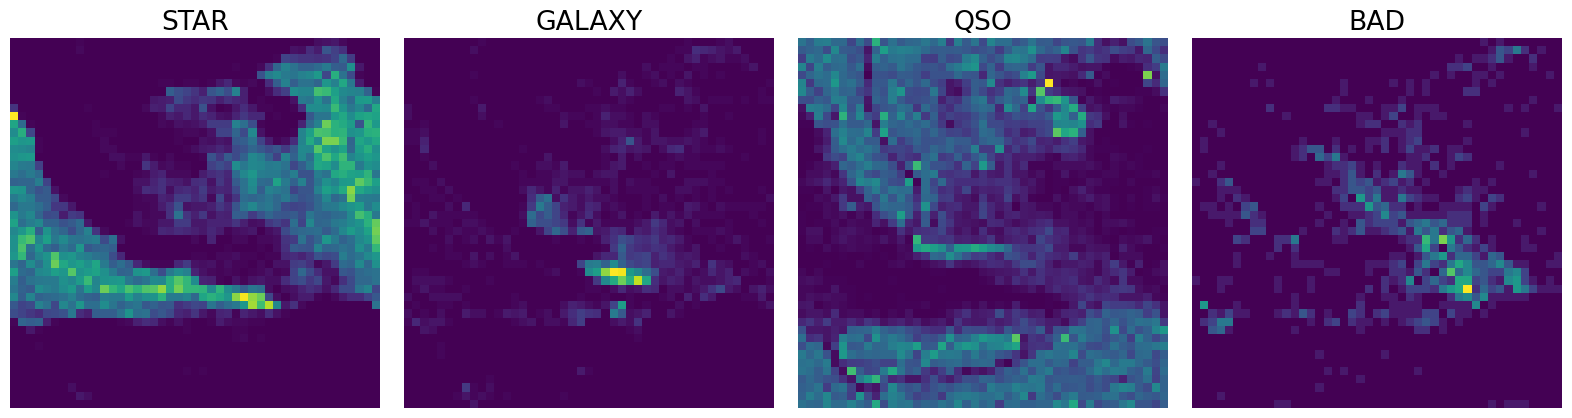

In [6]:
def plot_all_bmu(combine_qso=False):
    if combine_qso:
        fig, ax = plt.subplots(1, 4, figsize=(16, 7), layout="constrained")
    else:
        fig, ax = plt.subplots(1, 5, figsize=(16, 7), layout="constrained")
        
    labels = np.argmax(Y[0:len(bmu)], axis=1)
    
    if combine_qso:
        possible_labels = ["STAR", "GALAXY", "QSO", "BAD"]
    else:
        possible_labels = ["STAR", "GALAXY", "QSO_LZ", "QSO_HZ", "BAD"]

    cur_max = 0
    for i in range(len(possible_labels)):
        l = possible_labels[i]
        
        if l == "QSO":
            idx = (labels == label_names.index("QSO_LZ")) | (labels == label_names.index("QSO_HZ"))
        else:
            idx = labels == label_names.index(l)
            
        idx = idx.flatten()
        counts = np.bincount(bmu[idx], minlength=som_size)
        counts = counts.reshape(som_shape)
        
        cur_max = np.max([np.max(counts), cur_max])
        
        ax[i].axis("off")
        ax[i].imshow(counts, vmin=0)#, vmax=cur_max)
        ax[i].set_title(l)
        
        print(l, np.max(counts))
        
    fig.tight_layout()
    # plt.subplots_adjust(left=0.01, bottom=None, right=0.4, top=None, wspace=None, hspace=None)
    plt.savefig("plots/som_all.pdf", bbox_inches="tight")
    
plot_all_bmu(True)